# Понижение размерности

## Цель работы

Ознакомиться с основными методами понижения размерности, изучить их применение на практике, сравнить эффективность разных методов и визуализировать результаты.

## Содержание работы

1. Сгенерируйте синтетический двумерный датасет с высокой степенью корреляции между признаками.
1. Понизьте размерность датасета до одной при помощи метода PCA и визуализируйте его до и после.
1. Примените метод главных компонент на более многомерных данных. Визуализируйте две главные компоненты.
1. Выберите оптимальное количество главных компонент по методу локтя.
1. Сгенерируйте двумерный датасет для классификации и примените на нем метод линейного дискриминантного анализа.
1. Сгенерируйте двумерный датасет для классификации и примените на нем метод понижения размерности t-SNE.
1. Сгенерируйте линейно неразделимый двумерный датасет для классификации и опробуйте на нем метод KernelPCA с различными ядрами.

## Методические указания

В ходе выполнения этой работы мы познакомимся со разными методами понижения размерности. Эта задача в машинном обучении часто используется для визуализации многомерных данных, снижения объема данных, улучшения качества классификации, устранения мультиколлинеарности признаков. При этом, существуют разные методы понижения размерности, которые отличаются друг от друга не только по внутреннему устройству, но и по "техническим характеристикам", области применения, достоинствам и недостаткам. Поэтому по итогам выполнения данной работы нужно сформировать понимание того, в каких случаях какие методы следует применять.

### PCA на сгенерированных данных

Самый распространенный метод понижения размерности - метод главных компонент, PCA. Для того, чтобы понять смысл и основной механизм этого метода, мы разберем его действия на нескольких примерах. Для начала - на искусственных данных. Метод главных компонент выделяет самые информативные "направления" в пространстве признаков. Проще всего увидеть это направление на таком датасете, который демонстрирует сильную корреляцию.

Сгенерируем такой набор признаков, для наглядности, двумерный:

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer, make_blobs, make_circles
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA

plt.style.use('seaborn-v0_8-darkgrid')

In [64]:
n_samples = 100
x = np.random.normal(0, 1, n_samples)
y = 2 * x + np.random.normal(0, 0.5, n_samples)
X = np.column_stack((x, y))

Можете сами варьировать численные параметры в этой генерации и смотреть, как это влияет на последующие результаты. В нашем случае датасет выглядит так:

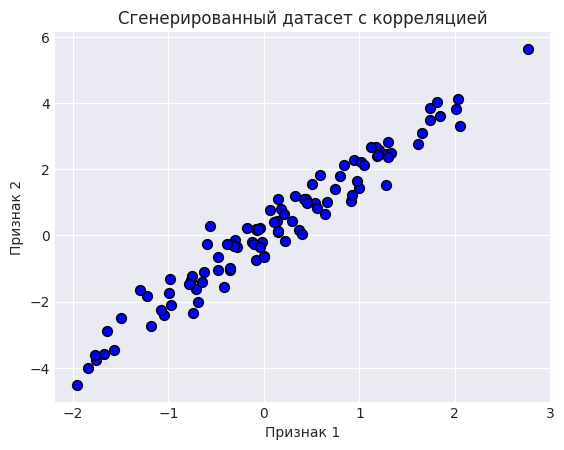

In [65]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
plt.title('Сгенерированный датасет с корреляцией')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.show()

Попробуем применить метод понижения размерности сразу, на данных как есть. Для этого импортируем класс данного метода из пакета decomposition.
Теперь мы создаем экземпляр класса. В конструкторе класса указываем количество компонент, которые хотим оставить в данных. Так как у нас всего два измерения, придется оставлять только одно:

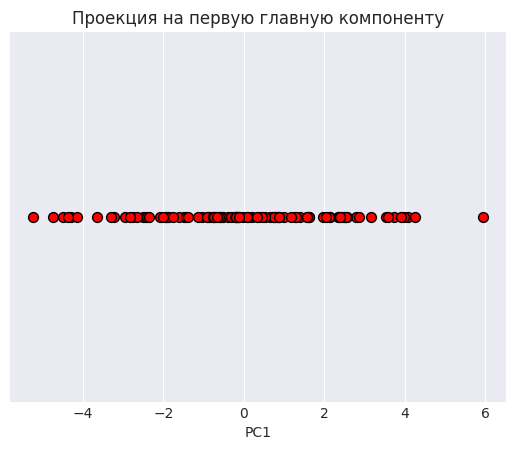

In [66]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)
plt.title('Проекция на первую главную компоненту')
plt.xlabel('PC1')
plt.yticks([])
plt.grid(True)
plt.show()

Это распределение, по сути, представляет собой проекцию исходного множества точек на определенную прямую. Эта прямая представляет собой направление, вдоль которого дисперсия исходного распределения максимальна. Этот вектор (направление) как раз и представляет собой главную компоненту.

Информацию о главной компоненте можно получить в соответствующих свойствах обученного объекта:

In [67]:
print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Главная компонента (направление): [[0.44087134 0.89757031]]
Объясненная дисперсия: [0.99232838]


Первое свойство хранит набор векторов главных компонент. Так как в нашем случае мы оставили только одно измерение, и главная компонента тоже будет одна. Это двумерный вектор, который и представляет собой направление в исходном пространстве.
Второй список хранит доли объясненной дисперсии по главным компонентам. Тут у нас опять только одно значение. Оно значит, что понижение размерности с двух до одного измерения сохраняет почти всю дисперсию.

В нашем случае двумерных данных можно очень наглядно визуализировать главную компоненту в исходном распределении. Можно изобразить вектор этого направления на диаграмме рассеяния:

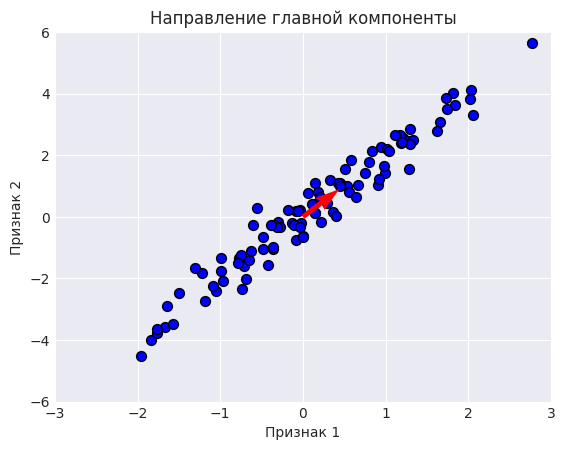

In [68]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
plt.title('Направление главной компоненты')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.xlim(-3, 3)
plt.ylim(-6, 6)
plt.show()

Попробуйте самостоятельно изменить параметры исходного распределения и посмотреть, как это влияет на направление главной компоненты.

На практике, данные перед применение метода понижения размерности необходимо нормировать. Посмотрим, как нормировка данных влияет на результат. Воспользуемся уже известным методом стандартизации:

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Теперь воспользуемся тем же методом понижения размерности, но уже обучим его на масштабированных данных:

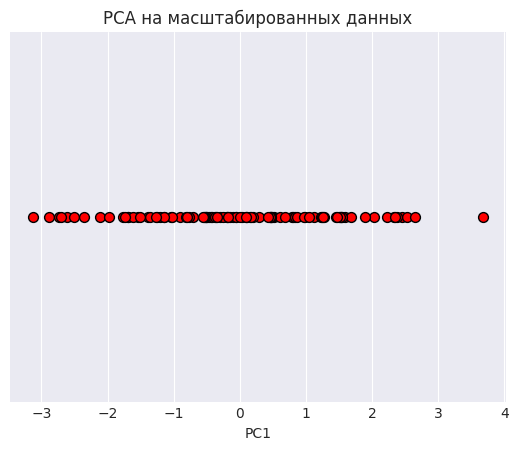

In [70]:
pca = PCA(n_components=1)
X_pca_scaled = pca.fit_transform(X_scaled)

plt.scatter(X_pca_scaled, np.zeros_like(X_pca_scaled), c='red', edgecolor='k', s=50)
plt.title('PCA на масштабированных данных')
plt.xlabel('PC1')
plt.yticks([])
plt.grid(True)
plt.show()

Так как решкалирование в целом сохраняет внутренние структуры, то есть расстояния между точками, это не влияет на результат понижения размерности (за исключением масштаба данных).

### PCA на многомерных данных

По аналогии проследим работу того же алгоритма, но уже на данных, состоящих из большего количества измерений. Для примера возьмем встроенный датасет о диагностике рака:

In [71]:
data = load_breast_cancer()
X = data.data
y = data.target
print(f"Форма исходных данных: {X.shape}")

Форма исходных данных: (569, 30)


Этот набор данных содержит 30 столбцов. Это хорошее число, имеет смысл уменьшить. Пока запомним, что в исходных данных именно 30 столбцов, это пригодится позднее.

Теперь применим метод главных компонент. Сейчас выберем уже две главные компоненты. В таком случае результат можно будет визуализировать. Обратите внимание, что мы обязательно применяем нормализацию:

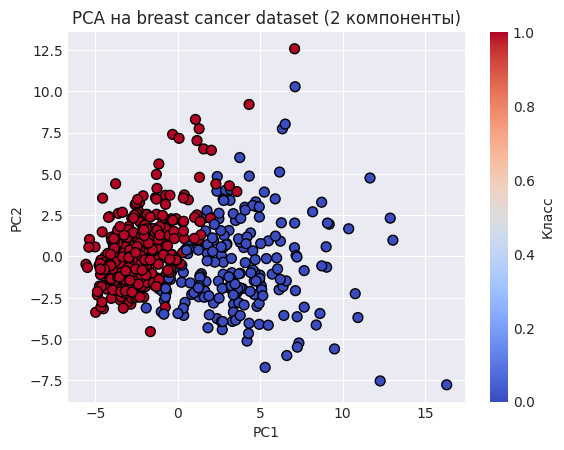

In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('PCA на breast cancer dataset (2 компоненты)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Класс')
plt.grid(True)
plt.show()

Если вы задаетесь вопросом, что именно отложено по осям, то ответ может вас разочаровать - главные компоненты. Никакого предметного смысла они не несут.

Мы здесь видим, по сути, проекцию набора точек из тридцатимерного пространства на плоскость. Причем эта плоскость расположена внутри этого тридцатимерного пространства таким образом, чтобы сохранить максимальную дисперсию. Другими словами, эта плоскость расположена так, чтобы в проекции точки были максимально разбросаны.

Можно задаться вопросом, как эта плоскость расположена внутри этого тридцатимерного пространства. Плоскость задается двумя векторами. Именно эти вектора и есть главные компоненты - направления, вдоль которых дисперсия максимальна.

In [73]:
print(f"Главные компоненты (направления): {pca.components_}")

Главные компоненты (направления): [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


В отличие от предыдущего примера, мы все-таки очень сильно сократили размерность. Это значит, что точки все равно сильно сместились относительно своего изначального положения в проекцию. То есть часть данных мы потеряли. Давайте посмотрим, какую именно часть выборочной дисперсии мы сохранили после понижения размерности:

In [74]:
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


В соответствующем свойстве объекта модели лежит массив, который показывает долю сохраненной (объясненной) дисперсии данных по каждой компоненте. Здесь мы видим, что проекция на первую главную компоненту сохраняет около 44% дисперсии исходных данных. Это значит, что если бы мы сократили размерность до одной, то потеряли бы 56% исходной информации.
Введение второй компоненты добавляет еще примерно 19% дисперсии. Таким образом, всего у нас получается около 63%. Можно считать, что понижение размерности в данном случае приводит к потере 37% информации о разбросе точек, имеющейся в исходном наборе.

### Метод локтя для PCA

Метод понижения размерности полезен для визуализации данных, но применяют его не только для этого. Он может быть хорошим помощником в тех случаях, когда в исходных данных слишком много признаков, их число надо сократить, но так, чтобы максимально сохранить имеющуюся информацию. В таком случае встает вопрос выбора количества компонент.

При определении оптимального количества компонент следует ориентироваться на то, насколько быстро растет количество информации в зависимости от количества измерений. Для того, чтобы отследить эту зависимость, построим график. Для этого построим алгоритм главных компонент с количеством компонент от 1 до 30:

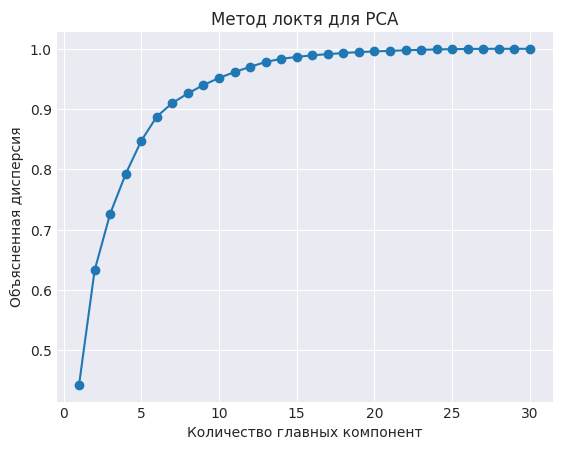

In [75]:
n_components_range = range(1, 31)
explained_variance = []

for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

plt.plot(n_components_range, explained_variance, marker='o')
plt.title('Метод локтя для PCA')
plt.xlabel('Количество главных компонент')
plt.ylabel('Объясненная дисперсия')
plt.grid(True)
plt.show()

Смысл в том, чтобы найти такое количество, которое дает оптимальное количество сохраненной информации. Для этого найдем такое значение, в котором данная кривая максимально изгибается. Это и будет локоть. Можно предположить, что в данном случае оптимальное количество 6 или 7 компонент. Если брать больше, дополнительные измерения уже не обеспечат такого значительного прироста информации.

In [76]:
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


Обратите внимание, что в данном методе первые компоненты не зависят от того, сколько компонент мы задали. Другими словами, метод всегда найдет одну и ту же главную компоненту, ее положение не зависит от количества компонент, которые мы оставляем. То есть, задание количества компонент по сути является лишь критерием остановки алгоритма.

Именно поэтому если мы построим две первые главные компоненты этой семимерной модели, они будут полностью идентичны предыдущей модели:

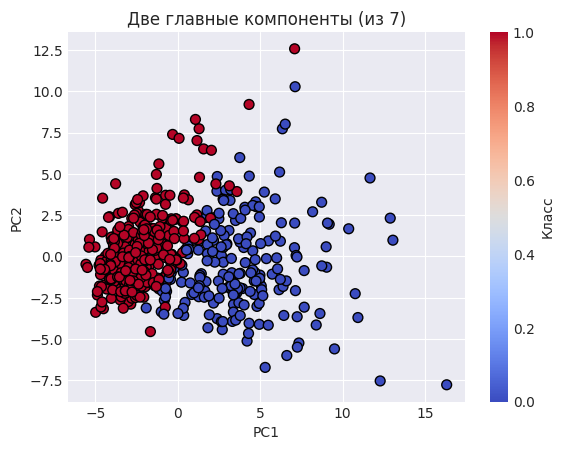

In [77]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('Две главные компоненты (из 7)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Класс')
plt.grid(True)
plt.show()

Это, в частности значит, что для выбора количества компонент методом локтя необязательно было обучать тридцать моделей подряд. Попробуйте самостоятельно достичь того же результата, но гораздо более рациональным способом.

### Метод LDA

Метод главных компонент неплохо работает в большинстве случаев. Однако, у него есть один недостаток - он принимает во внимание только взаимное расположение точек. Если перед вами датасет для классификации, этот метод может найти такие компоненты, то есть такие направления в исходном пространстве, после проекции на которые, точки разных классов могут оказаться еще ближе друг к другу, чем были в исходном распределении. Это может сильно осложнить задачу классификации, когда после проекции точки классов перемешаются.

Именно для решения этой проблемы существует метод линейного дискриминантного анализа. Он принимает во внимание значение целевой переменной. И выбирает направления проекции таким образом, чтобы максимизировать расстояние между классами. Рассмотрим, например, такой датасет:

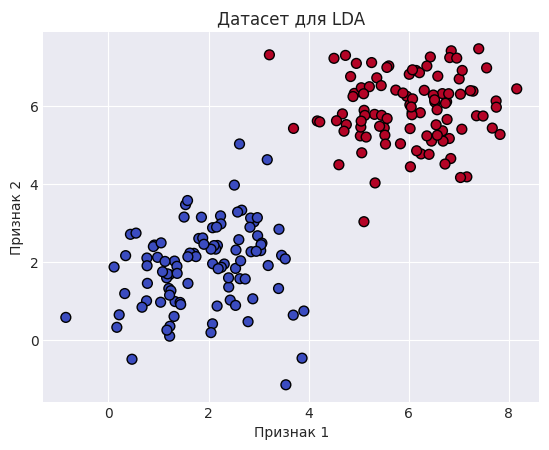

In [78]:
n_samples = 100
x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('Датасет для LDA')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.show()

Легко представить себе, что проецируя это распределение вдоль некоторых направлений, изначально очень разделимые классы могут полностью перемешаться. Посмотрим, как этому препятствует метод LDA. Интерфейс у класса этого метода, конечно, точно такой же, как и у предыдущего:

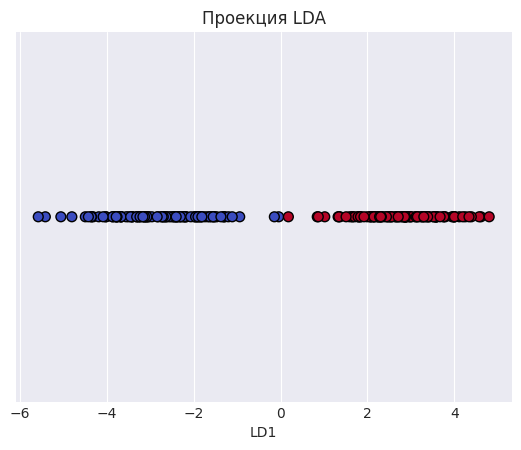

In [79]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('Проекция LDA')
plt.xlabel('LD1')
plt.yticks([])
plt.grid(True)
plt.show()

На рисунке в проекции видно, что классы остались линейно разделимыми.

Как и в предыдущем методе, мы можем найти информацию о направлении проекции в исходном пространстве. Для этого в методе LDA есть свойство intercept:

In [80]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[8.64261623 8.60713483]]


В данном случае, это свойство содержит один двумерный вектор. Именно его можно использовать для визуализации направления проекции:

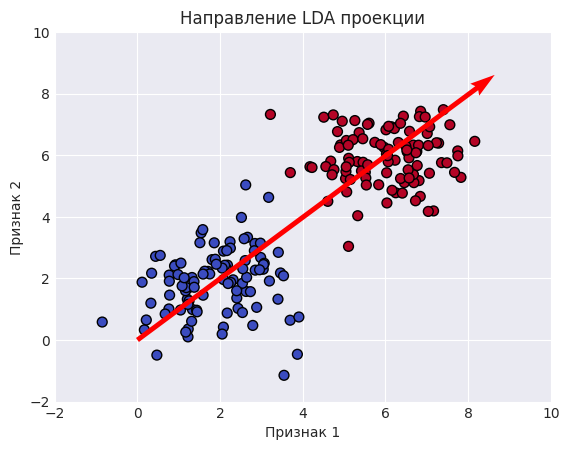

In [81]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
lda_direction = lda.coef_[0]
plt.quiver(0, 0, lda_direction[0], lda_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
plt.title('Направление LDA проекции')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.xlim(-2, 10)
plt.ylim(-2, 10)
plt.show()

### Метод LDA для анизотропных классов

В примере выше вы можете самостоятельно сравнить результаты работы метода LDA и метода главных компонент. В данном случае они дадут очень схожие результаты. Но в ряде случаем можно наглядно показать, чем они отличаются. Рассмотри такой датасет:

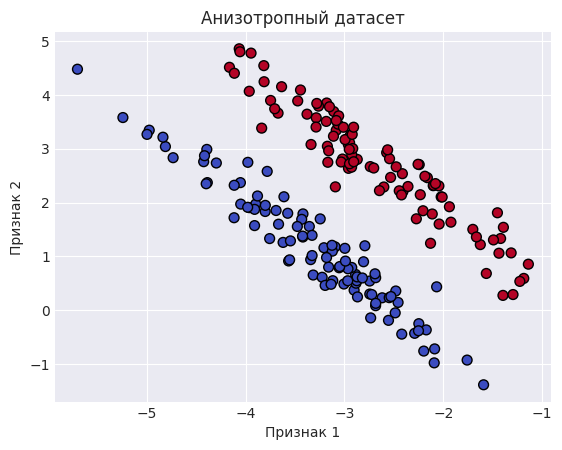

In [82]:
X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('Анизотропный датасет')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.show()

Легко заметить, что направление максимальной дисперсии в данном случае приведет к полному перемешиванию классов в данной выборке. Мы увидим это на практике в сравнении двух методов.

Сперва обучим метод линейного дискриминантного анализа на этих данных. Вот как выглядит результат понижения размерности:

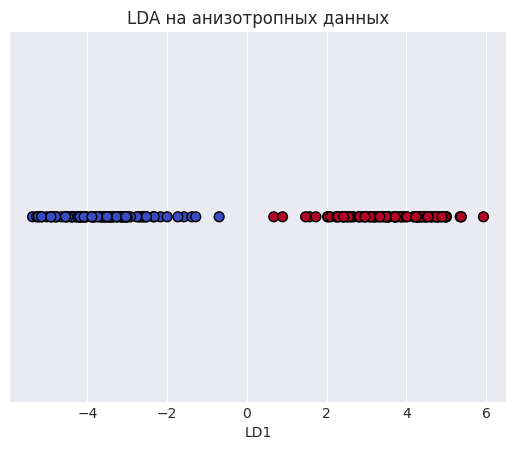

In [83]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('LDA на анизотропных данных')
plt.xlabel('LD1')
plt.yticks([])
plt.grid(True)
plt.show()

Классы остались разделимыми. Более наглядно можно увидеть, как именно произошла проекция в исходном пространстве:

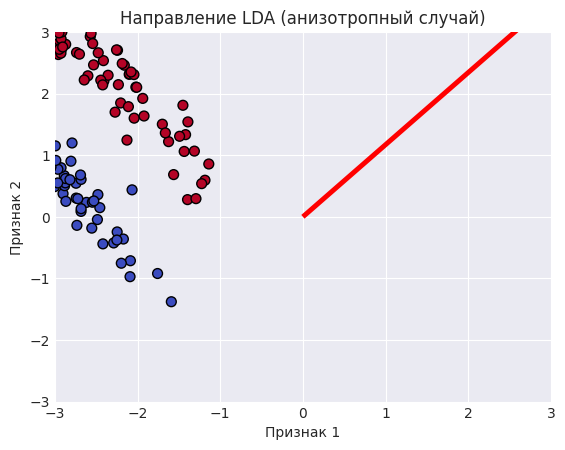

In [84]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
lda_direction = lda.coef_[0]
plt.quiver(0, 0, lda_direction[0], lda_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
plt.title('Направление LDA (анизотропный случай)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

Алгоритм выбрал именно то направление, которое сохраняет разделимость классов. Примечательно то, что метод главных компонент не принимает во внимание значение целевой переменной и, как следствие, приводит к совершенно другой проекции. Вот как выглядит прямая, на которую осуществляется проецирование в методе главных компонент:

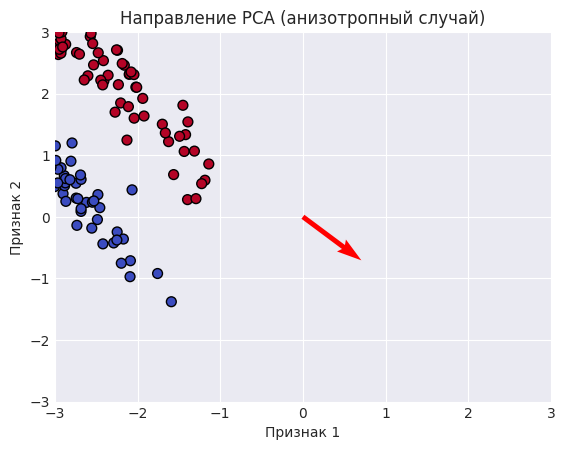

In [85]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
plt.title('Направление PCA (анизотропный случай)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

Соответственно, после проекции датасет выглядит так:

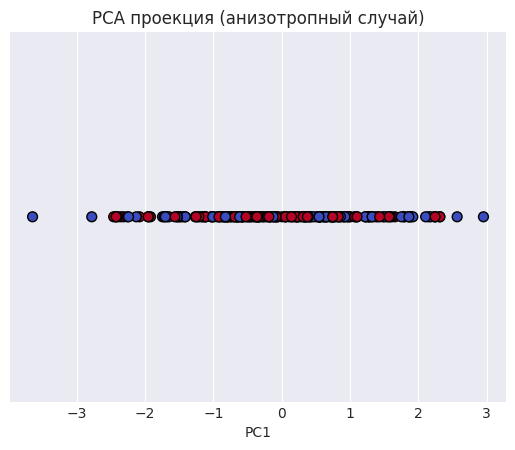

In [86]:
plt.scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('PCA проекция (анизотропный случай)')
plt.xlabel('PC1')
plt.yticks([])
plt.grid(True)
plt.show()

Понижение размерности методом главных компонент, несомненно, сохраняет гарантированно больше информации от исходного распределения. Но если применять его в качестве предварительного этапа обработки данных перед классификацией, то пользы от метода линейного дискриминантного анализа может быть значительно больше.

### Метод t-SNE

Рассмотрим еще один интересный метод понижения размерности - t-SNE. Он часто используется для визуализации кластеров - то есть близких групп точек в наборе данных. Давайте рассмотрим механизм его действия на примере уже использованного нами датасета для классификации:

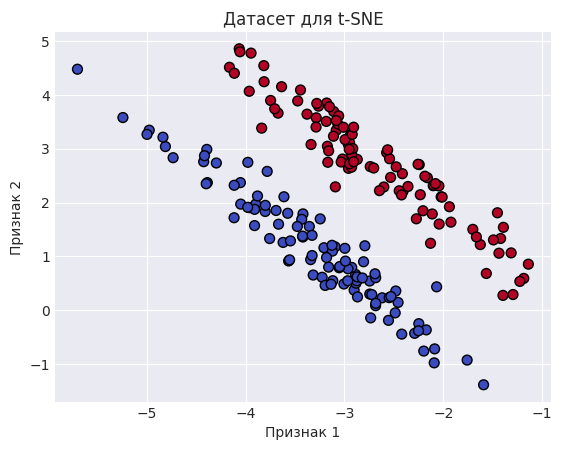

In [87]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('Датасет для t-SNE')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.show()

Для обучения метода, как всегда импортируем соответствующий класс. Его интерфейс не отличается от других классов, реализующих алгоритмы обучения без учителя:

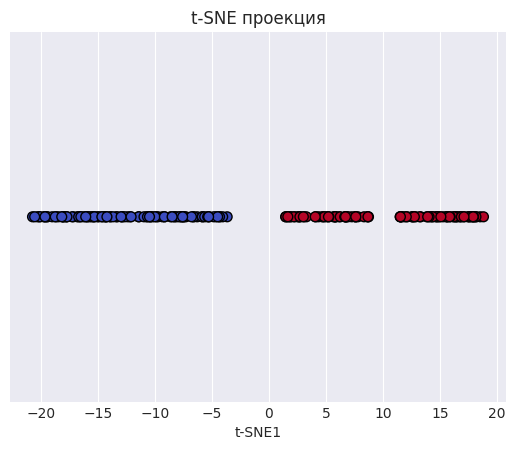

In [88]:
tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('t-SNE проекция')
plt.xlabel('t-SNE1')
plt.yticks([])
plt.grid(True)
plt.show()

Результат работы тоже не удивляет своей оригинальностью. Мы видим два различных кластера точек, которые соответствуют двум исходным классам в датасете.

Однако, имейте в виду, что данному алгоритму нигде не передавались метки классов, то есть значение целевой переменной. Алгоритм выделил эти группы точек самостоятельно, ориентируясь исключительно на их схожесть.

Самостоятельно проверьте работу этого алгоритма на созданном в предыдущем пункте анизотропном датасете.

Алгоритм t-SNE является параметрическим. У него есть один главный гиперпараметр, который существенно влияет на работу алгоритма. Это так называемый perplexity - он влияет на то, какие структуры будут превалировать в анализе, крупномасштабные или мелкие.

Теоретически очень сложно прочувствовать влияние этого параметра на суть работы алгоритма. Поэтому мы попробуем разные значения на практике. Авторы алгоритма рекомендуют в качестве рабочего диапазона значений этого параметра разброс от 5 до 50. Попробуем несколько конкретных значений из этого диапазона:

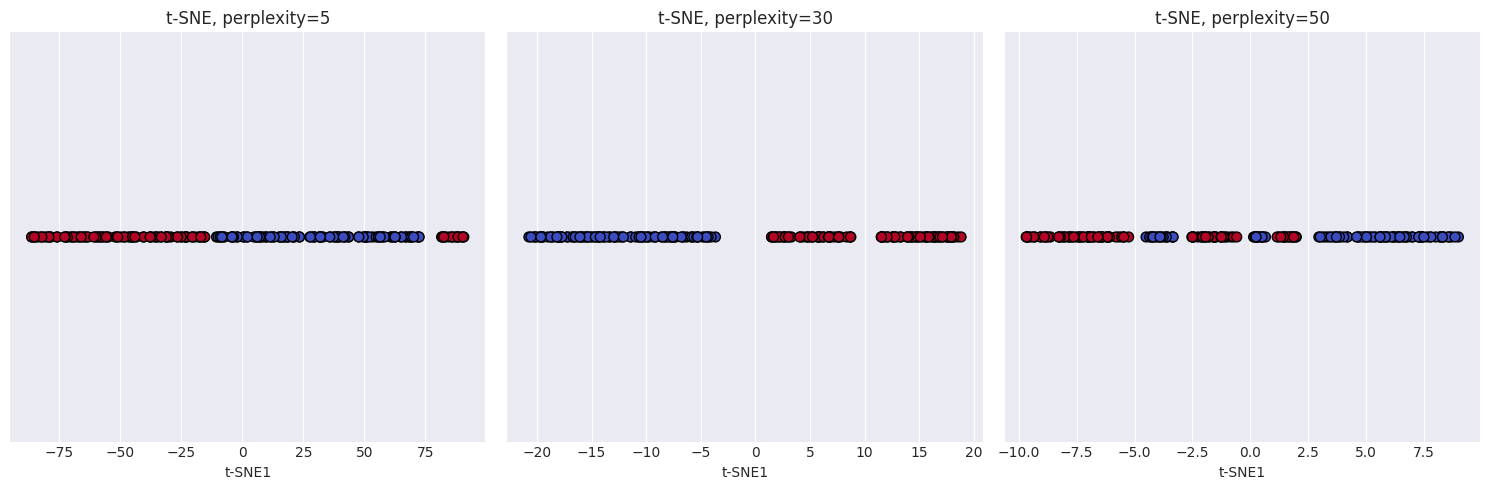

In [89]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))

for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='coolwarm', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('t-SNE1')
    plt.yticks([])
    plt.grid(True)
plt.tight_layout()
plt.show()

Мы видим разное формирование кластеров точек в зависимости от значения perplexity.
Конечно, в таком одномерном варианте сложно оценить формирование структур в данных. Поэтому самостоятельно проверьте работу этого алгоритма на более многомерных данных.

### Kernel PCA для нелинейных данных

Из рассмотренных выше моделей только t-SNE является нелинейным. Два предыдущие методы осуществляют только линейные преобразования исходного пространства. Однако, для некоторых методов возможно применение трюка с ядерными функциями, то есть введение нелинейного преобразования.

Давайте посмотрим датасет с линейно неразделимыми классами:

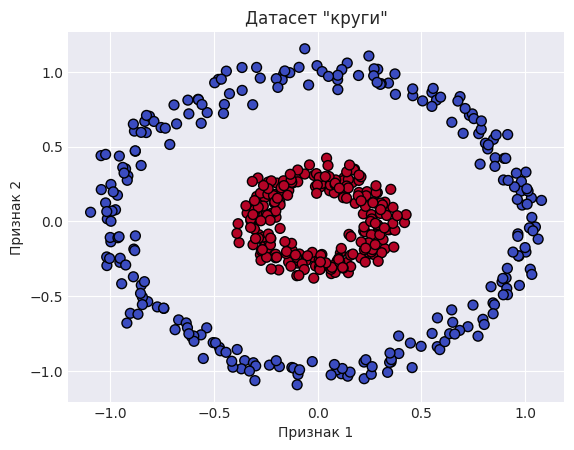

In [90]:
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.title('Датасет "круги"')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True)
plt.show()

Это довольно часто используемый искусственный датасет с ярко выраженной нелинейностью.

Ядерные функции работают в методе главных компонент примерно также, как и в методе опорных векторов. И ядерные функции используются такие же. Мы попробуем три самые распространенные:

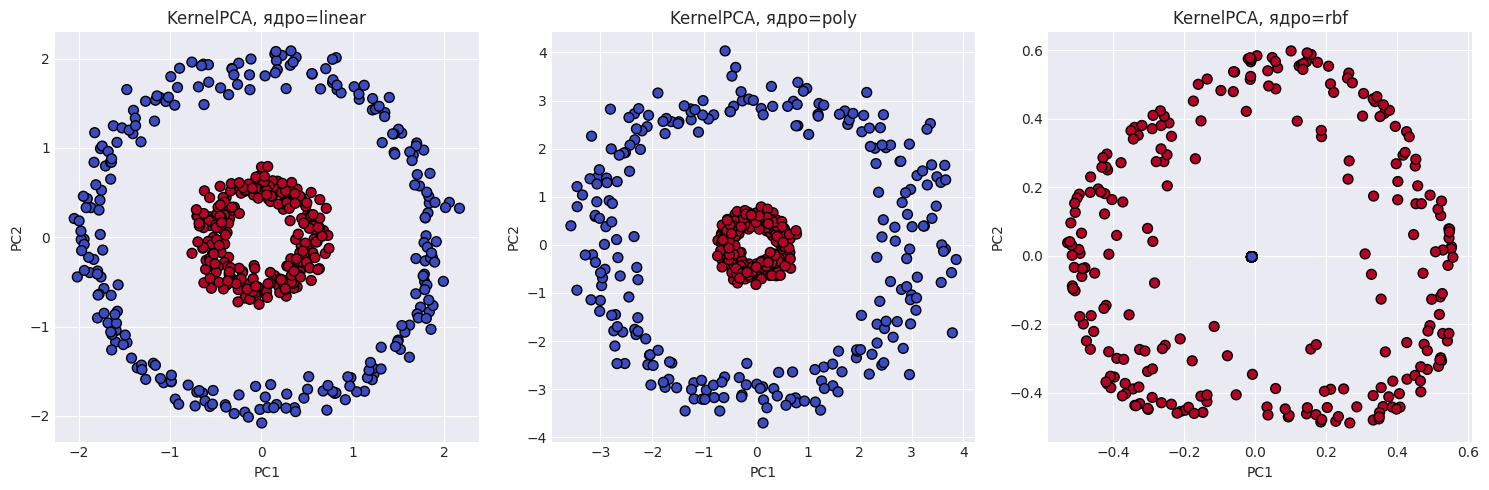

In [91]:
kernels = ['linear', 'poly', 'rbf']
plt.figure(figsize=(15, 5))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for i, kernel in enumerate(kernels):
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=10 if kernel == 'rbf' else None, random_state=42)
    X_kpca = kpca.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
    plt.title(f'KernelPCA, ядро={kernel}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
plt.tight_layout()
plt.show()

Вот так выглядит итоговое преобразование по использованным функциям.

Кроме применения разных функций, можно вспомнить, что радиально-базисная ядерная функция параметризуется степенью гамма. Точно также эмпирически можно проверить разные значения этого гиперпараметра:

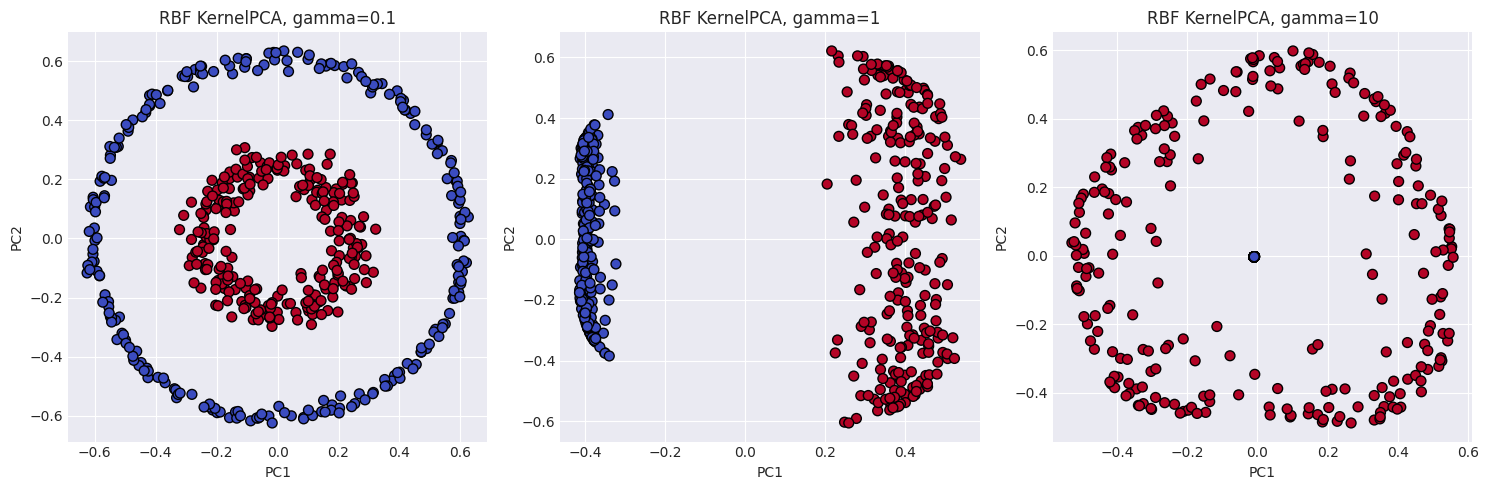

In [92]:
gamma_values = [0.1, 1, 10]
plt.figure(figsize=(15, 5))

for i, gamma in enumerate(gamma_values):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma, random_state=42)
    X_kpca = kpca.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
    plt.title(f'RBF KernelPCA, gamma={gamma}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
plt.tight_layout()
plt.show()

Самостоятельно попробуйте другие значения этого гиперпараметра, промежуточные, для того, чтобы прочувствовать его влияние на результат работы алгоритма.

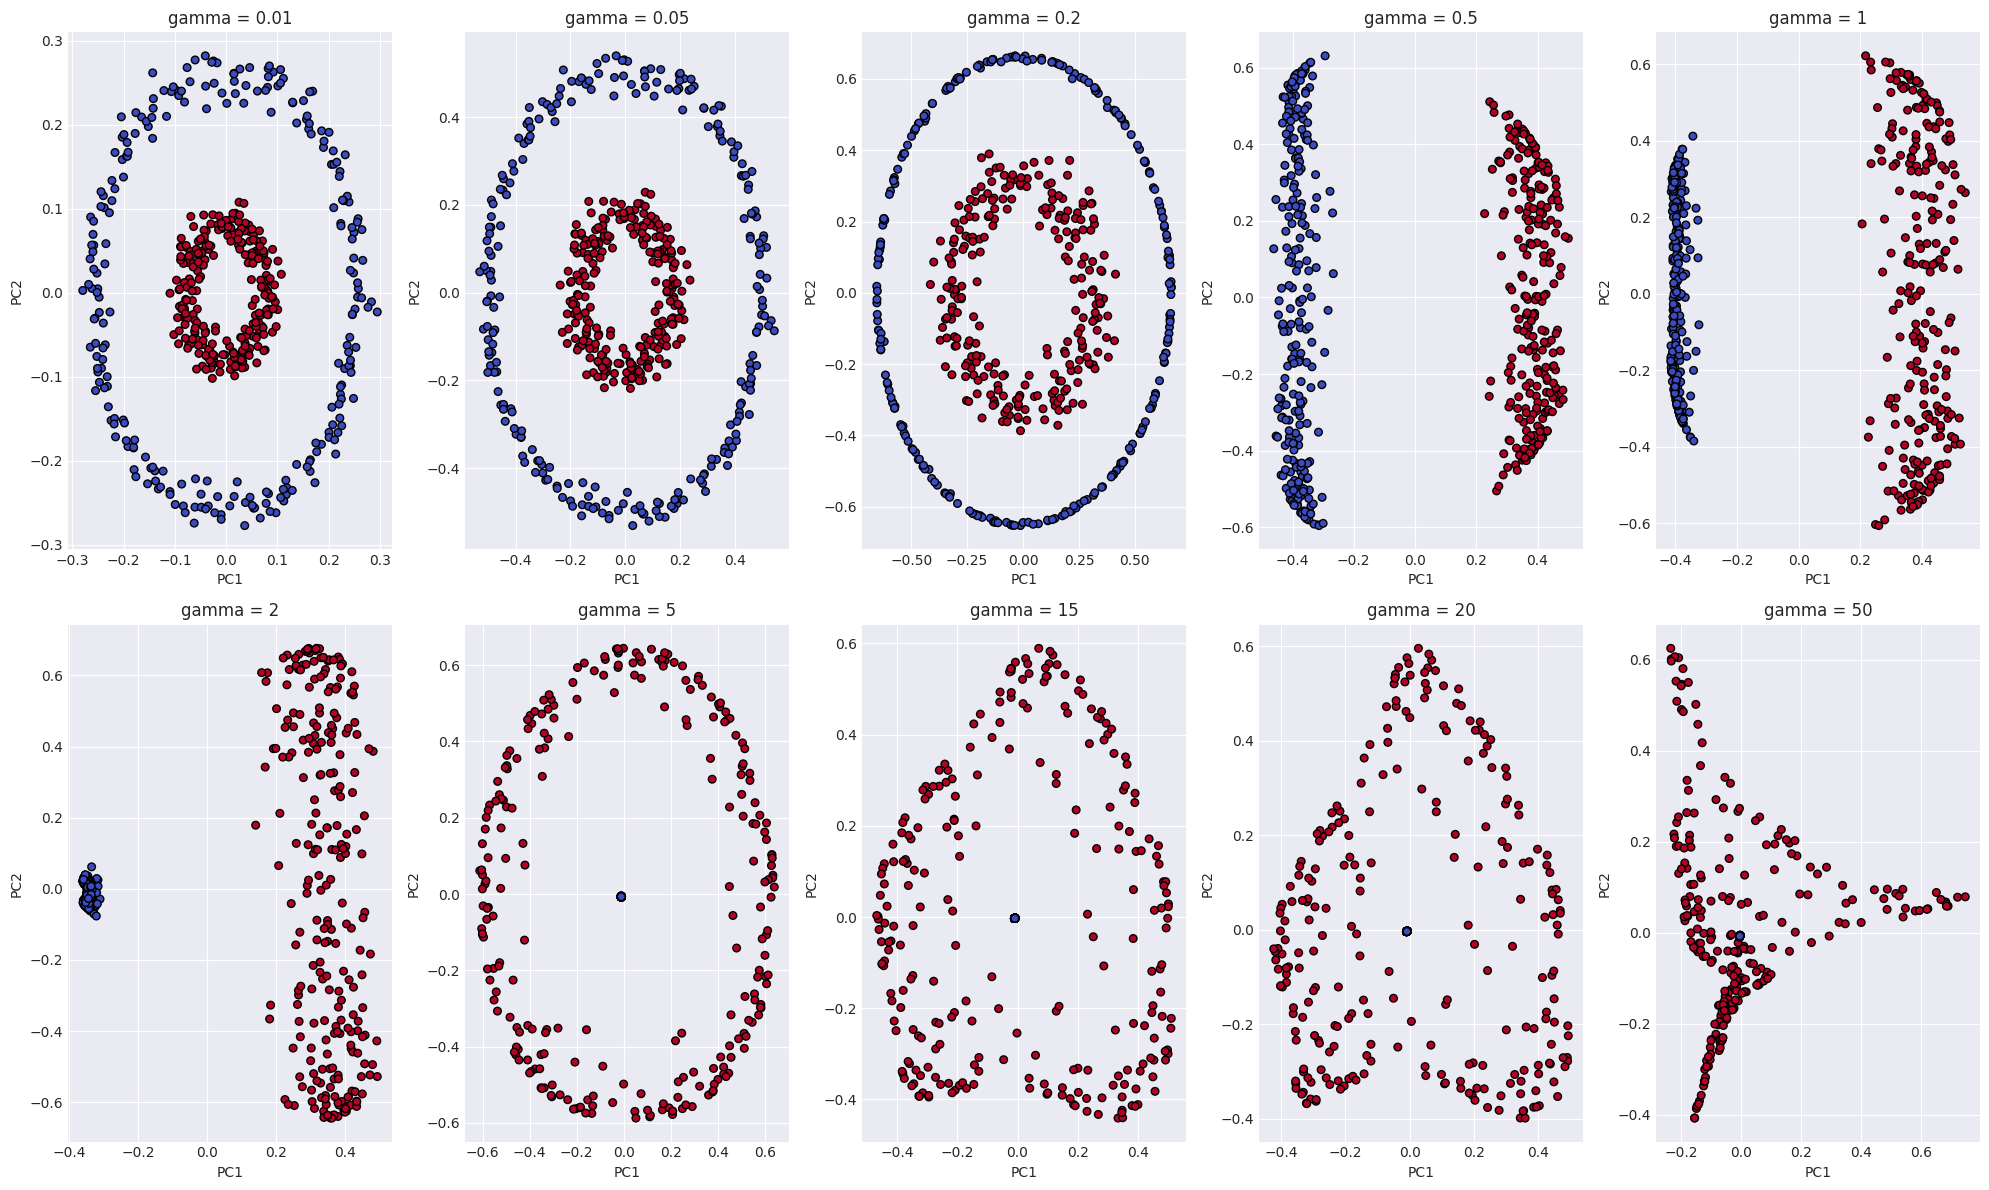

In [93]:
gamma_values = [0.01, 0.05, 0.2, 0.5, 1, 2, 5, 15, 20, 50]
plt.figure(figsize=(20, 12))

for i, gamma in enumerate(gamma_values):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma, random_state=42)
    X_kpca = kpca.fit_transform(X_scaled)
    
    plt.subplot(2, 5, i+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=30)
    plt.title(f'gamma = {gamma}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Контрольные вопросы

**1. В чем состоит задача понижения размерности? В каких случаях следует понижать размерность датасета?**

Задача понижения размерности — это преобразование исходного набора признаков (многомерного пространства) в новое пространство меньшей размерности с максимально возможным сохранением важной информации о структуре данных.

Понижать размерность датасета следует в следующих случаях: когда необходимо визуализировать многомерные данные (например, на плоскости или в 3D); когда признаки сильно коррелируют между собой (мультиколлинеарность), что мешает работе многих моделей; когда слишком большое количество признаков замедляет обучение модели или требует больших вычислительных ресурсов; для предотвращения переобучения, когда избыточные признаки могут приводить к тому, что модель запоминает шум вместо обобщения; а также для сжатия данных, когда нужно уменьшить объём хранимых данных, пожертвовав незначительной частью информации.

**2. В чем существенное различие изученных трех методов понижения размерности: PCA, LDA, t-SNE? В каких случаях какие следует применять?**

PCA (метод главных компонент) — это линейный метод обучения без учителя, который ищет направления максимальной дисперсии в данных. Его следует применять для общего сжатия данных, устранения корреляции между признаками или визуализации без учёта классов. Главный недостаток PCA в контексте классификации — он не учитывает целевую переменную и может спроецировать точки разных классов вперемешку.

LDA (линейный дискриминантный анализ) — это линейный метод обучения с учителем, который, в отличие от PCA, учитывает значение целевой переменной и выбирает направления проекции так, чтобы максимизировать расстояние между классами. Его следует применять в качестве этапа предобработки перед задачами классификации, когда важно сохранить разделимость классов после понижения размерности.

t-SNE — это нелинейный метод обучения без учителя, который сохраняет локальную структуру данных и хорошо выделяет кластеры, даже не зная меток классов. Его следует применять в первую очередь для визуализации сложных, нелинейных структур и обнаружения групп точек в данных. Однако t-SNE не рекомендуется использовать для сжатия данных или работы с тестовой выборкой, так как он не строит явное преобразование.

**3. Что такое главная компонента? Какой предметный смысл она несет?**

Главная компонента — это вектор (направление) в исходном пространстве признаков, вдоль которого дисперсия (разброс) данных максимальна. Первая главная компонента задаёт направление наибольшей вариативности, вторая — следующее за ней ортогональное направление и так далее.

Предметного смысла главные компоненты, как правило, не несут. Это математически найденные абстрактные направления, представляющие собой линейные комбинации исходных признаков. Например, в датасете о диагностике рака главная компонента не соответствует какому-либо реальному медицинскому показателю (например, размеру опухоли), а является сложной взвешенной суммой всех 30 исходных признаков, обеспечивающей максимальный разброс точек.

**4. В чем состоит компромисс при выборе количества компонент? Как работает для этой задачи метод локтя?**

Компромисс при выборе количества компонент заключается в балансе между двумя противоречивыми целями: с одной стороны, хочется сохранить как можно больше информации (объяснённой дисперсии), а с другой — получить максимальное сжатие данных, упростить визуализацию и ускорить вычисления. Добавление каждой новой компоненты увеличивает долю сохранённой информации, но уменьшает степень сжатия.

Метод локтя работает следующим образом: строится график зависимости суммарной объяснённой дисперсии от количества компонент. В начале, когда добавляются первые компоненты, график резко растёт, так как каждая новая компонента добавляет много информации. Затем прирост становится всё меньше, и график выполаживается. Точка изгиба этого графика называется "локтем" — именно она считается оптимальным количеством компонент, потому что добавление следующих компонент уже не даёт существенного выигрыша в сохранённой информации.

**5. Какой смысл и механизм действия у аргумента perplexity в методе понижения размерности t-SNE?**

Perplexity (перплексия) — это главный гиперпараметр метода t-SNE, который можно понимать как оценку эффективного количества ближайших соседей, учитываемых при анализе локальной структуры данных. Он определяет, на каких масштабах алгоритм фокусируется: на крупных или на мелких структурах.

Механизм действия perplexity заключается в регулировке ширины гауссианы, используемой для преобразования евклидовых расстояний между точками в вероятности сходства. Маленькое значение perplexity (например, 5) заставляет алгоритм обращать внимание только на очень близких соседей, что позволяет увидеть мелкие, локальные кластеры, но может привести к разрыву крупных структур на множество фрагментов. Большое значение perplexity (например, 50) заставляет алгоритм учитывать больше соседей, что показывает глобальную структуру данных, но может сгладить мелкие, но важные кластеры. Авторы метода рекомендуют выбирать perplexity в диапазоне от 5 до 50.